In [1]:
%load_ext autoreload    
%autoreload 2
from plot import *
import sys 
import torch.nn.functional as F
from tqdm import trange
sys.path.append('../')

In [2]:
# results_path = "../../results/sgd-steps"
# results_path = "../../results/move-32-features"
# results_path = "../../results/mnk"
# results_path = "../../results/mnk-10"
# results_path = "../../results/nsga-mnk"
# results_path = "../../results/nsga-iii-mnk"
# results_path = "../../results/l2-reg"
# results_path = "../../results/min-pruned"
# results_path = "../../results/test"
#cresults_path = "../../results/sgd-steps"
# results_path = "../../results/gecco-24/fourier-features-old"
# results_path = "../../results/gecco-24/sgd-steps"
# results_path = "../../results/telo-24-growth"
# results_path = "../../results/telo-25-sgd-10-nodes"
# results_path = "../../results/telo-25-sgd-inter"
results_path = "../../results/telo-25-sgd"
# results_path = "../../results/telo-24-growth-sgd-4"
# results_path = "../../results/topology-mutation-iters"
# results_path = "../../results/soft-mask-num-cells"
# results_path = "../../results/soft-mask"
# results_path = "../output/default"
# results_path = "../../results/n-ffts"
# results_path = "../../results/n-ffts-long"
# results_path = "../output/sgd_method"
# results_path = "../../results/topology-mutation-iters"
# results_path = "../../results/fourier-features"
# results_path = "/home/jackson/projects/move/results/fns-per-cell"

# results_path = "../../results/fourier-features-control"
# results_path = "../../results/sgd-lr-mutate-rate"
# results_path = "../../results/hillclimber"
# results_path = "../../results/hillclimber_bloat_prune/"
show=True


plot_dir = os.path.join(results_path, "plots")
os.makedirs(plot_dir, exist_ok=True)

In [3]:
from collections import OrderedDict
pretty_conditions = OrderedDict({
    "128_features": "128",
    "064_features": "64",
    "032_features": "32",
    "016_features": "16",
    "008_features": "8",
    "004_features": "4",
    "000_features": "0",
    "000_steps": "0 steps",
    "000_steps_": "0",
    "016_steps": "16 steps",
    "016_steps_": "16",
    "100_steps": "100 steps",
    "100_steps_": "100 steps",
    "1000_steps": "1000 steps",
    "1000_steps_": "1000",
    "original-move-0-steps-0-features": "MOVE",
    "MOVE-SGD-Slow-Growth": "Slow Growth",
    "MOVE-SGD-Fast-Grow": "Fast Growth",
    "MOVE-SGD-Start-Small-No-Grow": "Start Small (no growth)",
    "MOVE-SGD-Start-Big-No-Grow": "Start Big (no growth)",
    "MOVE-SGD-Grow-And-Prune": "Grow and Prune",
    "MOVE-SGD-Grow-And-Prune-No-Min-500-steps": "Grow and Prune 500 Steps",
    "MOVE-SGD-Grow-And-Prune-No-Min-0-steps": "Grow and Prune 0 Steps",
    "MOVE-SGD-Fast-Grow-0-steps": "Fast Grow 0 Steps",
    "MOVE-SGD-Fast-Grow-500-steps": "Fast Grow 500 Steps",
    "1000_steps_every_025_evolve_False": "1000 SGD / 25 Evolve (no inter. selection)",
    "1000_steps_every_025_evolve_True": "1000 SGD / 25 Evolve",
    "100_steps_every_025_evolve_False": "100 SGD / 25 Evolve (no inter. selection)",
    "100_steps_every_025_evolve_True": "100 SGD / 25 Evolve",
    "100_steps_every_010_evolve_True": "100 SGD / 10 Evolve",
    "100_steps_every_010_evolve_False": "100 SGD / 10 Evolve (no inter. selection)",
    "1000_steps_every_050_evolve_False": "1000 SGD / 50 Evolve (no inter. selection)",
    "1000_steps_every_050_evolve_True": "1000 SGD / 50 Evolve",
    "100_steps_every_050_evolve_False": "100 SGD / 50 Evolve (no inter. selection)",
    "100_steps_every_050_evolve_True": "100 SGD / 50 Evolve",
    "100_steps_every_100_evolve_True": "100 SGD / 100 Evolve",
    "100_steps_every_100_evolve_False": "100 SGD / 100 Evolve (no inter. selection)",
    "1000_steps_every_100_evolve_False": "1000 SGD / 100 Evolve (no inter. selection)",
    "1000_steps_every_100_evolve_True": "1000 SGD / 100 Evolve",
    
})



In [4]:
conds_path = os.path.join(results_path, "conditions")
df = pd.DataFrame()

REPLACEMENTS = []
CONDS = []
RUNS = []
TARGETS = []
FITNESS = []
TIME = []
IDS = []


for cond in os.listdir(conds_path):
    cond_path = os.path.join(conds_path, cond)
    runs = os.listdir(cond_path)
    for run in runs:
        run_path = os.path.join(cond_path, run)
        r_path = os.path.join(run_path, "replacements_by_batch.pt")
        e_path = os.path.join(run_path, "evals_by_batch.pt")
        i_path = os.path.join(run_path, "ids_by_batch.pt")
        f_path = os.path.join(run_path, "fitness_by_batch.pt")
        t_path = os.path.join(run_path, "target.txt")
        # print(os.listdir(run_path))
        if not os.path.exists(r_path): continue
        if not os.path.exists(e_path): continue
        if not os.path.exists(f_path): continue
        if not os.path.exists(t_path): continue
        target = open(t_path).readlines()[0]
        d = torch.load(r_path) # cells_from, cells_to, batches
        e = torch.load(e_path) # n_step_fwds, n_step_fwds_incl_sgd,n_step_evals,n_step_evals_incl_sgd,n_step_passes
        f = torch.load(f_path) # fns, cells, batches
        # check if all nan/-inf
        if torch.isnan(f).all() or torch.isinf(f).all(): continue
        if torch.isnan(d).all() or torch.isinf(d).all(): continue

        ids = torch.load(i_path) # shape = (cells, batches)
        number_of_unique_ids_per_batch = []
        for batch in range(ids.shape[1]):
            unique_ids = torch.unique(ids[:, batch])
            # check if all -1
            if (unique_ids == -1).all():
                break
            number_of_unique_ids_per_batch.append(len(unique_ids))

        # cut off once all 0s for ids:
       
        unique_ids_per_batch = torch.tensor(number_of_unique_ids_per_batch)

            # return_counts=True)[1]
        total_replacements = d.sum(dim=(0, 1))

        REPLACEMENTS.append(total_replacements)
        IDS.append(unique_ids_per_batch)
        CONDS.append(cond)
        RUNS.append(run)
        # T.append(e[..., -1].cpu())
        TIME.append(range(d.shape[-1]))
        FITNESS.append(f)
        TARGETS.append(target)



In [ ]:
IDS

[tensor([12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
         12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
         12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
         12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
         12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
         12, 12, 12, 12, 12, 12, 12, 12, 12,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,

In [ ]:
fit_df = pd.DataFrame({
    "condition": CONDS,
    "run": RUNS,
    "fitness": FITNESS,
    "target": TARGETS,
    # "time": TIME
})

filtered_keys = list(k for k in pretty_conditions.keys() if k in fit_df['condition'].unique())
fit_df['condition'] = pd.Categorical(fit_df['condition'], categories=filtered_keys, ordered=True)
fit_df = fit_df.sort_values('condition')

fit_df['condition'] = fit_df['condition'].apply(lambda x: pretty_conditions.get(x, x))
fit_df

,condition,run,fitness,target
84,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,"[[[tensor(0.7321), tensor(0.8488), tensor(0.83...",data/apple.png
101,1000 SGD / 25 Evolve (no inter. selection),run_14241842716863959536,"[[[tensor(0.8884), tensor(0.8832), tensor(0.90...",data/dolphin.png
100,1000 SGD / 25 Evolve (no inter. selection),run_14198392413927772656,"[[[tensor(0.8758), tensor(0.8076), tensor(0.81...",data/skull.png
99,1000 SGD / 25 Evolve (no inter. selection),run_2618126415922401776,"[[[tensor(0.9316), tensor(0.9468), tensor(0.96...",data/sunrise.png
98,1000 SGD / 25 Evolve (no inter. selection),run_201006164191744496,"[[[tensor(0.6558), tensor(0.6518), tensor(0.69...",data/spiral.png
...,...,...,...,...
4,1000 SGD / 100 Evolve,run_10546456480343593456,"[[[tensor(0.5000), tensor(0.5000), tensor(0.50...",data/checkers.png
3,1000 SGD / 100 Evolve,run_13631260545353257456,"[[[tensor(0.6306), tensor(0.6306), tensor(0.63...",data/spiral.png
2,1000 SGD / 100 Evolve,run_1729726131696701936,"[[[tensor(0.8132), tensor(0.8132), tensor(0.81...",data/linear_sin.png
1,1000 SGD / 100 Evolve,run_13272012335198638576,"[[[tensor(0.7517), tensor(0.7517), tensor(0.75...",data/spiral.png


In [ ]:
max_fit_df = fit_df.copy()
max_fit_df["fitness"] = max_fit_df["fitness"].apply(lambda x: x.mean(dim=0).max(dim=0)[0].max(dim=0)[0].item())

max_fit_df

,condition,run,fitness,target
84,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,0.501963,data/apple.png
101,1000 SGD / 25 Evolve (no inter. selection),run_14241842716863959536,0.343008,data/dolphin.png
100,1000 SGD / 25 Evolve (no inter. selection),run_14198392413927772656,0.432287,data/skull.png
99,1000 SGD / 25 Evolve (no inter. selection),run_2618126415922401776,0.489911,data/sunrise.png
98,1000 SGD / 25 Evolve (no inter. selection),run_201006164191744496,0.388709,data/spiral.png
...,...,...,...,...
4,1000 SGD / 100 Evolve,run_10546456480343593456,0.856186,data/checkers.png
3,1000 SGD / 100 Evolve,run_13631260545353257456,0.528027,data/spiral.png
2,1000 SGD / 100 Evolve,run_1729726131696701936,0.716994,data/linear_sin.png
1,1000 SGD / 100 Evolve,run_13272012335198638576,0.482504,data/spiral.png


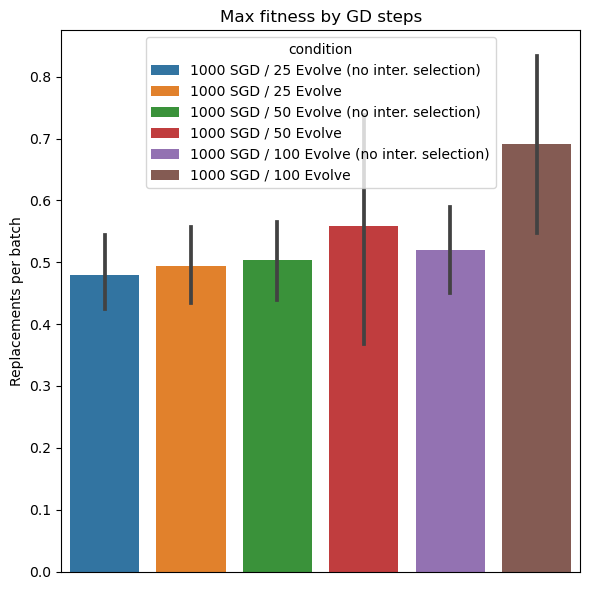

In [ ]:
# barplot by condition
plt.figure(figsize=(6, 6))
sns.barplot(data=max_fit_df, x="condition", hue="condition", y="fitness", dodge=False)
# increase bar width

plt.xticks([],[])
plt.title("Max fitness by GD steps")
plt.xlabel("")
plt.ylabel("Replacements per batch")
# plt.xticks(rotation=25, ha='right')
# legend outside
# legend from x ticks
# plt.legend(
    # title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "replacements_by_condition_bar.pdf"), bbox_inches='tight')
plt.show()

In [ ]:
EXPLODE = False
if EXPLODE:
    # dimension 0 : fn index
    fit_df_long = fit_df.explode(["fitness"], ignore_index=True)
    fit_df_long["fn_index"] = fit_df_long.groupby(["condition", "run"]).cumcount()

    # dimension 1 : cell index
    fit_df_long = fit_df_long.explode("fitness", ignore_index=True)
    fit_df_long["cell_index"] = fit_df_long.groupby(["condition", "run", "fn_index"]).cumcount()

    # dimension 2 : time step
    fit_df_long = fit_df_long.explode("fitness", ignore_index=True)
    fit_df_long["time_step"] = fit_df_long.groupby(["condition", "run", "fn_index", "cell_index"]).cumcount()

else:
    # take means
    # dimension 0 : fns
    fit_df_long = fit_df.copy()
    fit_df_long['fitness'] = fit_df_long['fitness'].apply(lambda x: x.mean(dim=0))
    # dimension 1 : cells
    fit_df_long['fitness'] = fit_df_long['fitness'].apply(lambda x: x.max(dim=0)[0])
    fit_df_long = fit_df_long.explode("fitness", ignore_index=True)
    fit_df_long["time_step"] = fit_df_long.groupby(["condition", "run"]).cumcount()
    fit_df_long = fit_df_long[fit_df_long['fitness']>=-1e8]

    fit_df_long['fitness'] = fit_df_long['fitness'].apply(lambda x: x.item())

    # drop na
    fit_df_long = fit_df_long.dropna().reset_index(drop=True)

fit_df_long



,condition,run,fitness,target,time_step
0,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,0
1,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,1
2,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,2
3,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,3
4,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,4
...,...,...,...,...,...
85495,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,995
85496,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,996
85497,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,997
85498,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,998


In [ ]:
# proportional time_step
fit_df_long["time_prop"] = fit_df_long.groupby(["condition", "run"])["time_step"].transform(lambda x: 1000.0*(x / x.max()))
fit_df_long['batch'] = fit_df_long['time_step']

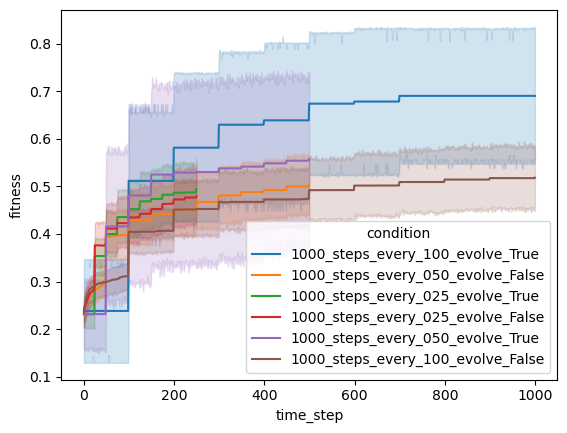

In [ ]:
sns.lineplot(data=fit_df_long, x="time_step", y="fitness", hue="condition")
plt.show()

In [ ]:
fit_df_long

,condition,run,fitness,target,time_step,time_prop,batch
0,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,0,0.000000,0
1,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,1,1.001001,1
2,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,2,2.002002,2
3,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,3,3.003003,3
4,1000_steps_every_100_evolve_True,run_10274984010026127856,0.365040,data/checkers.png,4,4.004004,4
...,...,...,...,...,...,...,...
85495,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,995,995.995996,995
85496,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,996,996.996997,996
85497,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,997,997.997998,997
85498,1000_steps_every_100_evolve_False,run_14491885662613606896,0.437426,data/butterfly.png,998,998.998999,998


in plot:  ['1000_steps_every_100_evolve_True' '1000_steps_every_050_evolve_False'
 '1000_steps_every_025_evolve_True' '1000_steps_every_025_evolve_False'
 '1000_steps_every_050_evolve_True' '1000_steps_every_100_evolve_False']
in plot after mean:  ['1000_steps_every_025_evolve_False' '1000_steps_every_025_evolve_True'
 '1000_steps_every_050_evolve_False' '1000_steps_every_050_evolve_True'
 '1000_steps_every_100_evolve_False' '1000_steps_every_100_evolve_True']
results conditions ['1000_steps_every_025_evolve_False' '1000_steps_every_025_evolve_True'
 '1000_steps_every_050_evolve_False' '1000_steps_every_050_evolve_True'
 '1000_steps_every_100_evolve_False' '1000_steps_every_100_evolve_True']


KeyboardInterrupt: 

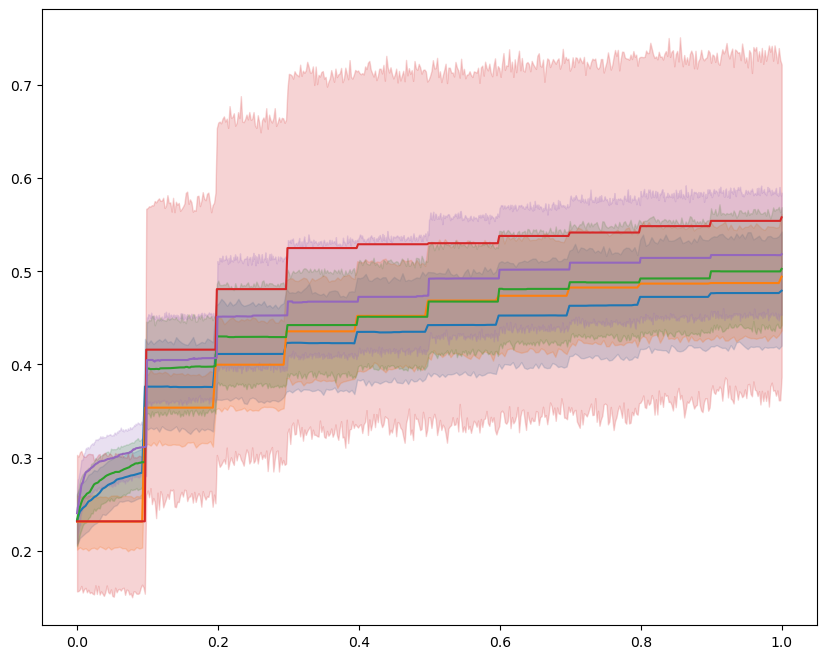

In [ ]:
plot_vs_evals(fit_df_long, save_path=plot_dir,
              y="fitness", x_var='time_prop', show=True, mean_by_target=True,x_axis_as_prop=True,)

In [ ]:
replace_df = pd.DataFrame({
    "condition": CONDS,
    "run": RUNS,
    "replacements": REPLACEMENTS,
    "target": TARGETS,
})

filtered_keys = list(k for k in pretty_conditions.keys() if k in replace_df['condition'].unique())
replace_df['condition'] = pd.Categorical(replace_df['condition'], categories=filtered_keys, ordered=True)
replace_df = replace_df.sort_values('condition')

replace_df['condition'] = replace_df['condition'].apply(lambda x: pretty_conditions.get(x, x))
replace_df

,condition,run,replacements,target
84,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,"[tensor(214.), tensor(204.), tensor(206.), ten...",data/apple.png
101,1000 SGD / 25 Evolve (no inter. selection),run_14241842716863959536,"[tensor(254.), tensor(168.), tensor(191.), ten...",data/dolphin.png
100,1000 SGD / 25 Evolve (no inter. selection),run_14198392413927772656,"[tensor(246.), tensor(125.), tensor(103.), ten...",data/skull.png
99,1000 SGD / 25 Evolve (no inter. selection),run_2618126415922401776,"[tensor(318.), tensor(172.), tensor(85.), tens...",data/sunrise.png
98,1000 SGD / 25 Evolve (no inter. selection),run_201006164191744496,"[tensor(333.), tensor(142.), tensor(235.), ten...",data/spiral.png
...,...,...,...,...
4,1000 SGD / 100 Evolve,run_10546456480343593456,"[tensor(133.), tensor(0.), tensor(0.), tensor(...",data/checkers.png
3,1000 SGD / 100 Evolve,run_13631260545353257456,"[tensor(312.), tensor(0.), tensor(0.), tensor(...",data/spiral.png
2,1000 SGD / 100 Evolve,run_1729726131696701936,"[tensor(234.), tensor(0.), tensor(0.), tensor(...",data/linear_sin.png
1,1000 SGD / 100 Evolve,run_13272012335198638576,"[tensor(270.), tensor(0.), tensor(0.), tensor(...",data/spiral.png


In [ ]:
# print the first replacement row
replace_df.iloc[0]['replacements']

tensor([214., 204., 206., 168.,  58.,  58.,  52., 111., 100.,  74.,  71.,  84.,
         79., 102.,  47., 101., 108.,  50.,  65.,  41.,  32.,  19.,  28.,  44.,
        197.,   4.,   3.,  43.,   7.,   0.,   5.,  14.,   9.,   3.,   1.,  13.,
         18.,   0.,  14.,   6.,  12.,   6.,   4.,  12.,   4.,  11.,   3.,  28.,
          6., 178.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,
          0.,   0.,   0.,   2.,   2.,   0.,   0.,   0.,   6.,   0.,   3.,   0.,
          0.,   0., 123.,   0.,   1.,   1.,   0.,  17.,  14.,   0.,   0.,   0.,
         10.,   6.,   1.,   2.,   4.,   3.,  12.,   2.,   0.,   0.,   0.,   0.,
          1.,   5.,   7., 134.,   7.,   0.,   2.,   3.,   9.,   5.,  11.,  11.,
          0.,   0.,   3.,   0.,   0.,   3.,   0.,   6.,   0.,   0.,   1.,   3.,
         15.,   2.,   0.,   2., 108.,   0.,   0.,   2.,   0.,   2.,   1.,   0.,
          1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          6.,   0.,   0.,   0.,   4.,  5

In [ ]:
num_jumps_df = replace_df.copy()

# num_jumps_df['jumps'] = num_jumps_df['replacements'].apply(lambda x:x.sum(dim=(0, 1).item()))
num_jumps_df = num_jumps_df.explode("replacements", ignore_index=True)

num_jumps_df['time_step'] = num_jumps_df.groupby(["condition", "run"]).cumcount()
num_jumps_df


,condition,run,replacements,target,time_step
0,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,tensor(214.),data/apple.png,0
1,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,tensor(204.),data/apple.png,1
2,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,tensor(206.),data/apple.png,2
3,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,tensor(168.),data/apple.png,3
4,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,tensor(58.),data/apple.png,4
...,...,...,...,...,...
124163,1000 SGD / 100 Evolve,run_10274984010026127856,tensor(0.),data/checkers.png,1425
124164,1000 SGD / 100 Evolve,run_10274984010026127856,tensor(0.),data/checkers.png,1426
124165,1000 SGD / 100 Evolve,run_10274984010026127856,tensor(0.),data/checkers.png,1427
124166,1000 SGD / 100 Evolve,run_10274984010026127856,tensor(0.),data/checkers.png,1428


In [ ]:
num_jumps_df['replacements'] = num_jumps_df['replacements'].apply(lambda x:x.item())

In [ ]:
# drop time_steps that are not in fit_df_long
num_jumps_df = num_jumps_df[num_jumps_df['time_step'].isin(fit_df_long['time_step'])]
num_jumps_df

,condition,run,replacements,target,time_step
0,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,214.0,data/apple.png,0
1,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,204.0,data/apple.png,1
2,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,206.0,data/apple.png,2
3,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,168.0,data/apple.png,3
4,1000 SGD / 25 Evolve (no inter. selection),run_15510059362954711536,58.0,data/apple.png,4
...,...,...,...,...,...
123733,1000 SGD / 100 Evolve,run_10274984010026127856,0.0,data/checkers.png,995
123734,1000 SGD / 100 Evolve,run_10274984010026127856,0.0,data/checkers.png,996
123735,1000 SGD / 100 Evolve,run_10274984010026127856,0.0,data/checkers.png,997
123736,1000 SGD / 100 Evolve,run_10274984010026127856,0.0,data/checkers.png,998


In [ ]:
# per run replacement means
mean_replace_df = num_jumps_df.groupby(["condition", "run"]).mean().reset_index()
mean_replace_df

/tmp/ipykernel_3704120/4029217609.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_replace_df = num_jumps_df.groupby(["condition", "run"]).mean().reset_index()


,condition,run,replacements,time_step
0,1000 SGD / 25 Evolve (no inter. selection),run_10211908506852332016,NaN,NaN
1,1000 SGD / 25 Evolve (no inter. selection),run_10274984010026127856,NaN,NaN
2,1000 SGD / 25 Evolve (no inter. selection),run_1029280307890360816,NaN,NaN
3,1000 SGD / 25 Evolve (no inter. selection),run_10348169204779192816,19.172507,185.0
4,1000 SGD / 25 Evolve (no inter. selection),run_10544733554212803056,NaN,NaN
...,...,...,...,...
1009,1000 SGD / 100 Evolve,run_9506398495712154096,NaN,NaN
1010,1000 SGD / 100 Evolve,run_9663921867308012016,NaN,NaN
1011,1000 SGD / 100 Evolve,run_9908852255788175856,NaN,NaN
1012,1000 SGD / 100 Evolve,run_9939656164961751536,NaN,NaN


In [ ]:
mean_replace_df['condition'].unique()

['1000 SGD / 25 Evolve (no inter. selection)', '1000 SGD / 25 Evolve', '1000 SGD / 50 Evolve (no inter. selection)', '1000 SGD / 50 Evolve', '1000 SGD / 100 Evolve (no inter. selection)', '1000 SGD / 100 Evolve']
Categories (6, object): ['1000 SGD / 25 Evolve (no inter. selection)' < '1000 SGD / 25 Evolve' < '1000 SGD / 50 Evolve (no inter. selection)' < '1000 SGD / 50 Evolve' < '1000 SGD / 100 Evolve (no inter. selection)' < '1000 SGD / 100 Evolve']

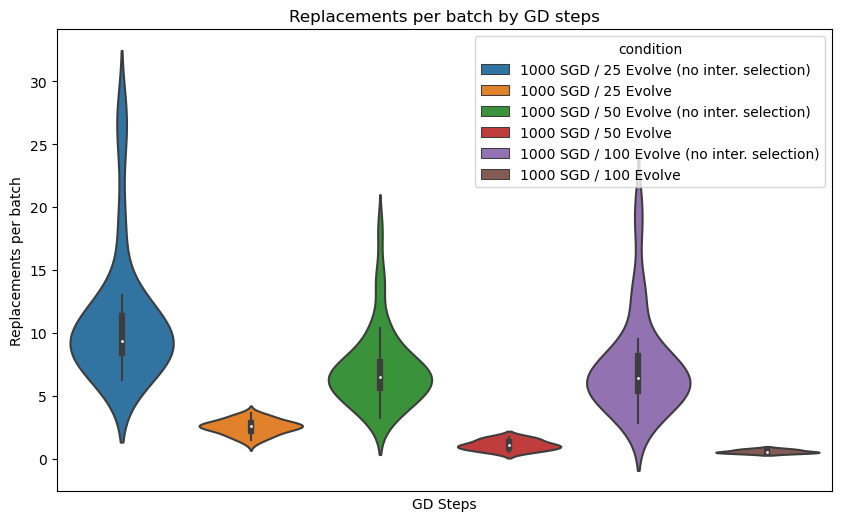

/users/j/s/jsdean/scratch/bin/miniconda3/envs/move/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


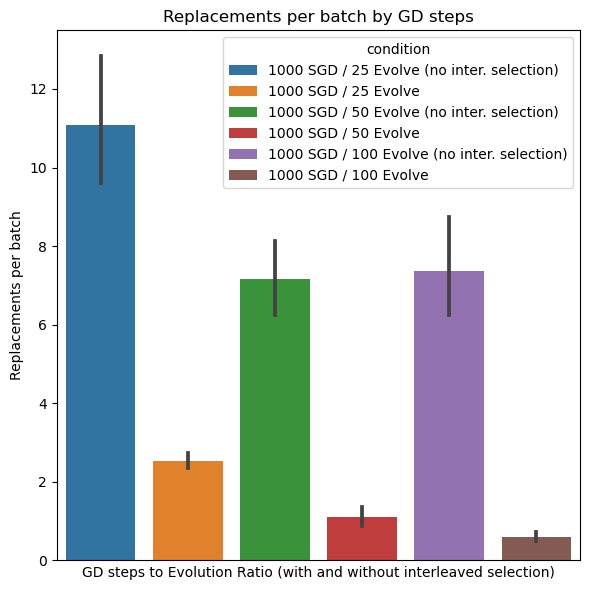

In [ ]:
# violin plot by condition
plt.figure(figsize=(10, 6))
sns.violinplot(data=mean_replace_df,  x="condition", hue="condition", y="replacements", dodge=False)
plt.title("Replacements per batch by GD steps")
plt.xlabel("GD Steps")
plt.ylabel("Replacements per batch")
plt.xticks(rotation=25, ha='right')
plt.savefig(os.path.join(plot_dir, "replacements_by_condition_violin.pdf"), bbox_inches='tight')
plt.xticks([])
plt.show()

# barplot by condition
plt.figure(figsize=(6, 6))
sns.barplot(data=mean_replace_df, x="condition", hue="condition", y="replacements",dodge=False)
# increase bar width

plt.xticks([],[])
plt.title("Replacements per batch by GD steps")
plt.xlabel("GD steps to Evolution Ratio (with and without interleaved selection)")
plt.ylabel("Replacements per batch")
# plt.xticks(rotation=25, ha='right')
# legend outside
# legend from x ticks
# plt.legend(
    # title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "replacements_by_condition_bar.pdf"), bbox_inches='tight')
plt.show()


In [ ]:
# plot number of ids per condition
id_df = pd.DataFrame({
    "condition": CONDS,
    "run": RUNS,
    "ids": IDS,
    "target": TARGETS,
})
id_df = id_df.explode("ids", ignore_index=True)
id_df['time_step'] = id_df.groupby(["condition", "run"]).cumcount()
id_df['ids'] = id_df['ids'].apply(lambda x:x.item())
print(list(k for k in pretty_conditions.keys() if k in id_df['condition'].unique()))
# order by OrderedDict pretty_conditions keys
filtered_keys = list(k for k in pretty_conditions.keys() if k in id_df['condition'].unique())
id_df['condition'] = pd.Categorical(id_df['condition'], categories=filtered_keys, ordered=True)
id_df = id_df.sort_values('condition')

id_df['condition'] = id_df['condition'].apply(lambda x: pretty_conditions.get(x, x))

id_df

['1000_steps_every_025_evolve_False', '1000_steps_every_025_evolve_True', '1000_steps_every_050_evolve_False', '1000_steps_every_050_evolve_True', '1000_steps_every_100_evolve_False', '1000_steps_every_100_evolve_True']


,condition,run,ids,target,time_step
42749,1000 SGD / 25 Evolve (no inter. selection),run_1958802395722813936,6,data/linear_sin.png,249
37836,1000 SGD / 25 Evolve (no inter. selection),run_12944645564209828336,19,data/maze.png,86
37835,1000 SGD / 25 Evolve (no inter. selection),run_12944645564209828336,15,data/maze.png,85
37834,1000 SGD / 25 Evolve (no inter. selection),run_12944645564209828336,13,data/maze.png,84
37833,1000 SGD / 25 Evolve (no inter. selection),run_12944645564209828336,11,data/maze.png,83
...,...,...,...,...,...
3335,1000 SGD / 100 Evolve,run_13631260545353257456,6,data/spiral.png,335
3336,1000 SGD / 100 Evolve,run_13631260545353257456,6,data/spiral.png,336
3337,1000 SGD / 100 Evolve,run_13631260545353257456,6,data/spiral.png,337
3330,1000 SGD / 100 Evolve,run_13631260545353257456,6,data/spiral.png,330


In [ ]:
id_df.groupby(['condition', 'run']).mean().reset_index()

/tmp/ipykernel_3704120/2397119854.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  id_df.groupby(['condition', 'run']).mean().reset_index()


,condition,run,ids,time_step
0,1000 SGD / 25 Evolve (no inter. selection),run_10211908506852332016,NaN,NaN
1,1000 SGD / 25 Evolve (no inter. selection),run_10274984010026127856,NaN,NaN
2,1000 SGD / 25 Evolve (no inter. selection),run_1029280307890360816,NaN,NaN
3,1000 SGD / 25 Evolve (no inter. selection),run_10348169204779192816,16.2,124.5
4,1000 SGD / 25 Evolve (no inter. selection),run_10544733554212803056,NaN,NaN
...,...,...,...,...
1009,1000 SGD / 100 Evolve,run_9506398495712154096,NaN,NaN
1010,1000 SGD / 100 Evolve,run_9663921867308012016,NaN,NaN
1011,1000 SGD / 100 Evolve,run_9908852255788175856,NaN,NaN
1012,1000 SGD / 100 Evolve,run_9939656164961751536,NaN,NaN


In [ ]:
list(k for k in pretty_conditions.keys() if k in id_df['condition'].unique())

[]

/tmp/ipykernel_3704120/2128784522.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.violinplot(data=id_df.groupby(['condition', 'run']).mean().reset_index().reset_index(), y='ids', x='condition', hue='condition', dodge=False)


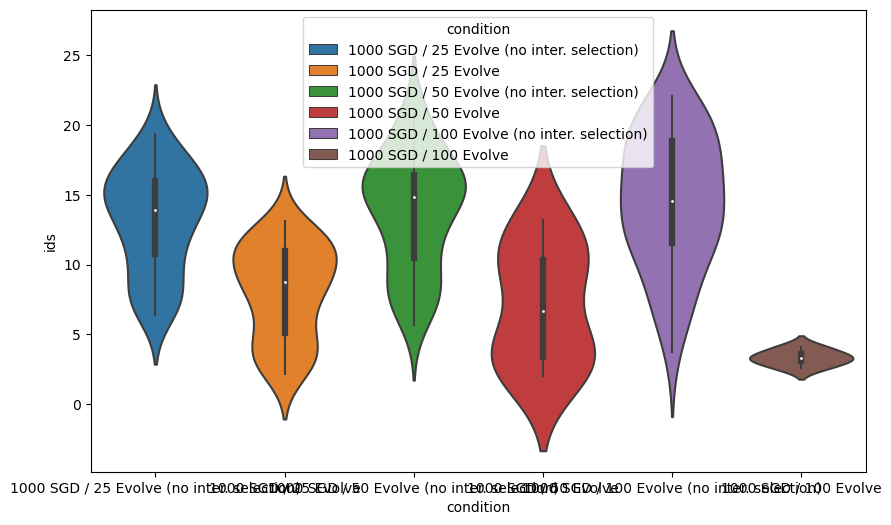

/tmp/ipykernel_3704120/2128784522.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.barplot(data=id_df.groupby(['condition', 'run']).mean().reset_index().reset_index(), y='ids', x='condition', hue='condition', dodge=False)
/users/j/s/jsdean/scratch/bin/miniconda3/envs/move/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


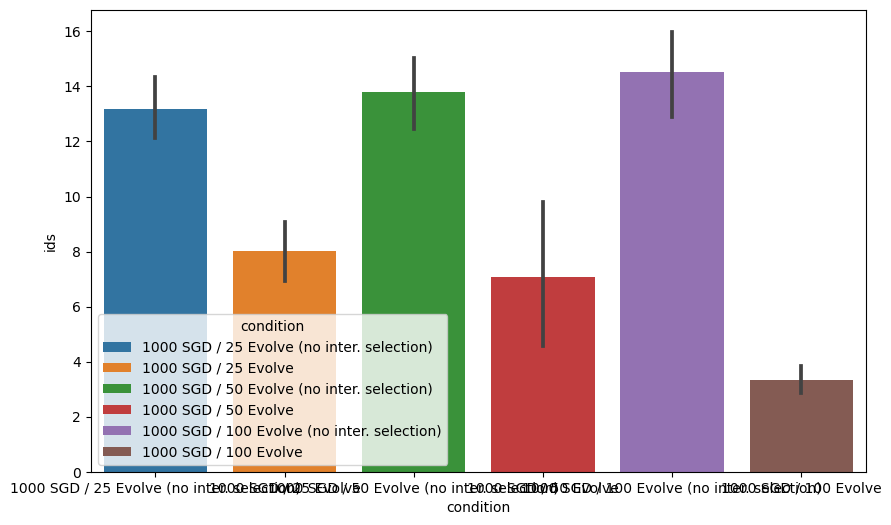

In [ ]:

plt.figure(figsize=(10, 6))
sns.violinplot(data=id_df.groupby(['condition', 'run']).mean().reset_index().reset_index(), y='ids', x='condition', hue='condition', dodge=False)
plt.savefig(os.path.join(plot_dir, "unique_ids_by_condition_violin.png"), bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=id_df.groupby(['condition', 'run']).mean().reset_index().reset_index(), y='ids', x='condition', hue='condition', dodge=False)
plt.savefig(os.path.join(plot_dir, "unique_ids_by_condition_bar.png"), bbox_inches='tight')
plt.show()


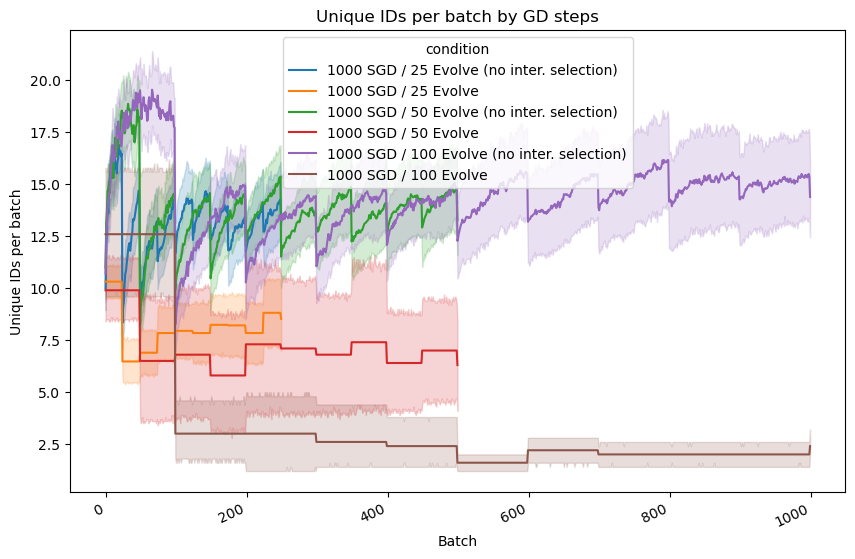

In [ ]:
# plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=id_df, x= 'time_step', y= 'ids', hue='condition')
plt.title("Unique IDs per batch by GD steps")
plt.xlabel("Batch")
plt.ylabel("Unique IDs per batch")
plt.xticks(rotation=25, ha='right')
plt.savefig(os.path.join(plot_dir, "unique_ids_by_condition.png"), bbox_inches='tight')
plt.show()


In [ ]:
# combine to dataframe
# df = pd.DataFrame({"replacements": D, "condition": C, "run": R})

# df


In [ ]:
if False:

    # pad so that the last dimension is the same length
    max_len = max([d.shape[-1] for d in D])
    print("Padding to length", max_len)

    for i in trange(len(D)):
        d = D[i]
        if d.shape[-1] < max_len:
            pad_width = max_len - d.shape[-1]
            pad = [0] * (d.ndim*2)
            pad[-1] = pad_width
            pad[-2] = 0
            D[i] = F.pad(d, pad, "constant", np.nan)
    df = pd.DataFrame({"replacements": D, "condition": C, "run": R})

df

""


In [ ]:

def read_tensor_results(results_path, names, fns =None, max_runs=None, reduce=True, only_final=False, condition_filter=None, max_batch=None, exclude_targets=[None, "None"]):
    cond_dir = os.path.join(results_path, "conditions")
    results = []
    
    total_expected_results = 0
    for name in names:
        for cond in os.listdir(cond_dir):
            if condition_filter is not None and cond not in condition_filter:
                    continue
            cond_path = os.path.join(cond_dir, cond)
            if not os.path.isdir(cond_path):
                continue
            runs = os.listdir(cond_path)[:max_runs] if max_runs is not None else os.listdir(cond_path)
            for run in runs:
                pt_path = os.path.join(cond_path, run, f"{name}.pt")
                if not os.path.exists(pt_path):
                    continue
                target_path = os.path.join(cond_path, run, "target.txt")
                if not os.path.exists(target_path):
                    target = None
                else:
                    with open(target_path, 'r') as f:
                        target = f.read().strip()
                if target in exclude_targets:
                    continue
                total_expected_results += 1

    # if not reduce and fns is None:
    #     print("Must specify fns to use for non-reduced results")
    #     return pd.DataFrame()

    for name in tqdm(names, desc="Loading"):
        try:
            df_index_offset = 0
            for cond in os.listdir(cond_dir):
                if condition_filter is not None and cond not in condition_filter:
                    continue
                cond_path = os.path.join(cond_dir, cond)
                if not os.path.isdir(cond_path):
                            continue
                runs = os.listdir(cond_path)[:max_runs] if max_runs is not None else os.listdir(cond_path)
                for run in runs:
                    pt_path = os.path.join(cond_path, run, f"{name}.pt")
                    if not os.path.exists(pt_path):
                        continue
                    t = torch.load(pt_path)
                    t = process_tensor(t, name, fns, reduce, max_batch)

                    if only_final:
                        last_row_not_nan = torch.isnan(t).sum(dim=0) == 0
                        t = t[:, last_row_not_nan]

                        t = t[..., -1].unsqueeze(-1)

                    if t is None:
                        print("Did not find tensor for", name, "at", pt_path)
                        continue

                    target_path = os.path.join(cond_path, run, "target.txt")
                    if not os.path.exists(target_path):
                        target = "None"
                    else:
                        with open(target_path, 'r') as f:
                            target = f.read().strip()
                    
                    cell_names_path = os.path.join(cond_path, run, "cell_names.csv")
                    if not os.path.exists(cell_names_path):
                        cells = []
                    else:
                        with open(os.path.join(cond_path, run, "cell_names.csv"), 'r') as f:
                            cells = list(csv.reader(f))[0]

                    if t.shape[0] == len(cells) and not reduce and os.path.exists(cell_names_path):
                        # t = t[t!= float('-inf')]
                        num_batches = t.shape[1]
                        num_cells = t.shape[0]
                        # Flatten the data and repeat the cell names
                        values = t.flatten()
                        cells = np.repeat(cells, num_batches)

                        # Create the DataFrame
                        df = pd.DataFrame({
                            'cell': cells,
                            # 'batch': batches,
                            name: values
                        })

                        
                    else:
                        names = [name]
                        if len(t.shape) > 1 and fns is not None:
                            names += [f for f in fns]
                        if name == 'replacements_by_batch':
                            # t is shape num_cells, num_cels, num_batches
                            # take t where either dim 0 or 1 is not 0
                            # Check for non-zero values in each batch
                            mask = (t.sum(dim=0) != 0) | (t.sum(dim=1) != 0)  # shape: (num_cells, num_batches)

                            # Collapse across num_cells to see if there's *any* non-zero value in either dim 0 or 1
                            batch_mask = mask.any(dim=0)  # shape: (num_batches,)

                            # Now index the tensor with the mask to select those batches
                            t = t[:, :, batch_mask]
                            results.append((cond, run, t.to_dense()))
                            # check if results is complete
                            print(len(results), total_expected_results)
                            if len(results) == total_expected_results:
                                del t
                                return results
                            continue # skip to next run
                        if fns is not None and (name=='normed_fitness_by_batch' or name=='fitness_by_batch'):
                            use_fns = fns
                            if "normed" in name:
                                use_fns = [f+"_normed" for f in fns]
                            df = pd.DataFrame(t.T.numpy(), columns=use_fns) 
                            for f in use_fns:
                                df = df[df[f].notna()]
                                df = df[df[f] != float('inf')]
                                df = df[df[f] != float('-inf')]
                                df = df[df[f] != float('nan')]
                                df = df[df[f] != float('NaN')]
                                df = df[df[f] != 'NaN']
                                # df = df.reset_index(drop=True)
                        else:
                            df = pd.DataFrame(t.numpy(), columns=names)

                            df = df[df[name].notna()]
                            df = df[df[name] != float('inf')]
                            df = df[df[name] != float('-inf')]
                            df = df[df[name] != float('nan')]
                            df = df[df[name] != float('NaN')]
                            df = df[df[name] != 'NaN']
                            df = df.reset_index(drop=True)

                    df["condition"] = cond
                    df["run"] = str(run)
                    df["target"] = target
                    if not only_final:
                        df["batch"] = df.index

                    df.index = df.index + df_index_offset
                    df_index_offset += len(df)
                    results.append(df)
                    del t
        except Exception as e:
            print("Error processing", name)
            print(e)
            print(traceback.format_exc())
            continue
        
    if len(results) == 0:
        print("No results found")
        return pd.DataFrame() 
    final_df = results[0]
    for df in tqdm(results[1:], desc="Merging"):
        final_df = final_df.combine_first(df)
    return final_df